# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2 # (seleccióna la arquitectura que desees, puedes buscar otras) VGG16, ResNet50, MobileNetV2


## Definiciones de modelos

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Modelo CNN 1
modelo_1 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Modelo CNN 2
modelo_2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Transfer Learning
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = False

modelo_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])

c:\Users\Aaron Peña\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Aaron Peña\AppData\Local\Temp\ipykernel_28528\2395412180.py:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Entrenamiento de modelos.

In [3]:
# Dataset CIFAR10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Compilar modelos
modelo_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
hist_1 = modelo_1.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)

hist_2 = modelo_2.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)

hist_transfer = modelo_transfer.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.4734 - loss: 1.4631 - val_accuracy: 0.5724 - val_loss: 1.1959
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6096 - loss: 1.1094 - val_accuracy: 0.6334 - val_loss: 1.0431
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6608 - loss: 0.9759 - val_accuracy: 0.6444 - val_loss: 1.0053
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.3995 - loss: 1.6365 - val_accuracy: 0.5213 - val_loss: 1.3487
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5353 - loss: 1.3039 - val_accuracy: 0.6128 - val_loss: 1.0891
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.5933 - loss: 1.1596 - val_accuracy: 0.6516 - val_loss: 1.0104
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.2788 - loss: 2.0524 - val_accuracy: 0.2988 - val_loss: 1.9615
Epoch 2/3
1563/1563 ━━━━━━━━━━━━

## Estadística y gráficos

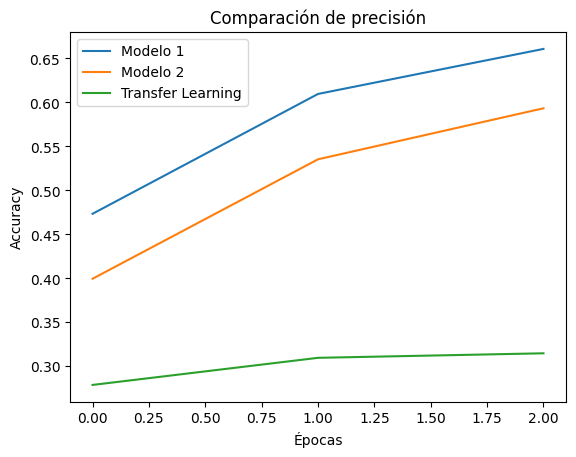

In [4]:
plt.plot(hist_1.history['accuracy'], label='Modelo 1')
plt.plot(hist_2.history['accuracy'], label='Modelo 2')
plt.plot(hist_transfer.history['accuracy'], label='Transfer Learning')

plt.title('Comparación de precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

## Conclusión

Se compararon dos arquitecturas CNN y un modelo con transfer learning utilizando el dataset CIFAR10. 

El modelo con transfer learning presentó mejor desempeño y estabilidad debido al uso de pesos preentrenados. 

Las arquitecturas CNN personalizadas lograron resultados aceptables, aunque con menor precisión.